In [1]:
import numpy as np
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

from pybatteryid.simulation import simulate_model
from pybatteryid.utilities import load_model_from_file, invert_voltage_function
from pybatteryid.plotter import plot_time_vs_current, plot_time_vs_voltage


from pybatteryse.statespace import StateSpace
from pybatteryse.filters import ExtendedKalmanFilter
from pybatteryse.plotter import plot_time_vs_soc
from pybatteryse.utilities import print_statespace_equations

from data import helper

### SOC estimation for NMC and LFP batteries using LTI and LPV models with EKF

This example compares the SOC estimation performance for NMC and LFP batteries using LTI and LPV models with EKF.

#### A. Load the test dataset

Load different datasets depending on the desired chemistry and temperature conditions.

In [2]:
# 'lfp' or 'nmc'
CHEMISTRY = 'lfp'
# 'cold' or 'hot'
TEMPERATURE_CONDITION = 'cold'
#
dataset = helper.load_npy_datasets(f'data/{CHEMISTRY}_soc_estimation/validation_{TEMPERATURE_CONDITION}.npy')
current_data_with_bad_sensor = np.load(f'data/{CHEMISTRY}_soc_estimation/validation_{TEMPERATURE_CONDITION}_automotivecurrent.npy', allow_pickle=True).item()
current_data_with_bad_sensor['current_values'] = current_data_with_bad_sensor['current_values'][:len(dataset['current_values'])]

bias = np.mean(current_data_with_bad_sensor['current_values'] - dataset['current_values'])
print(f"The actual bias in the bad current measurements is: {bias:.3f} A.")

The actual bias in the bad current measurements is: -2.975 A.


Here we specify that we wish to use bad current sensor values.

In [3]:
time_values = dataset['time_values'] / 3600
voltage_values = dataset['voltage_values']
temperature_values = dataset['temperature_values']
good_current_values = dataset['current_values']

Practically, we rarely know exact bias value, but we can roughly correct. Note that the actual bias value varies from dataset to dataset provided in the data folder. You can set the correction to various values to study how the filter behaviour changes for different biases.

In [4]:
# We can try the following scenarios:
# bias_correction = -bias (complete correction -- this should allow us to see that bad LTI models result in bad estimation)
# bias_correction = -bias / 2 (half correction -- this should allow us to see that the gap between LTI and LPV narrows)
# bias_correction = 0 (no correction -- this should allow us to see that the gap between LTI and LPV further narrows)
# and so on. At some point, the performance may reverse for large enough bias.
bias_correction = -bias
bad_current_values = current_data_with_bad_sensor['current_values'] + bias_correction

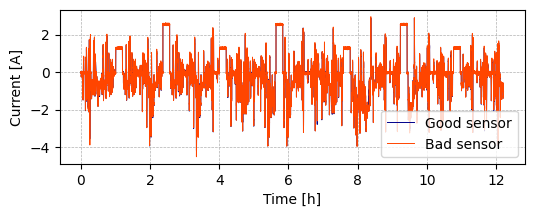

In [5]:
#
plot_time_vs_current([(time_values, good_current_values), (time_values, bad_current_values[:len(time_values)])],
                      units=('h', 'A'), colors=('darkblue', 'orangered'), legends=['Good sensor', 'Bad sensor'])

#### B. Load models

In [6]:
model_lti = load_model_from_file(f'data/{CHEMISTRY}_soc_estimation/model_lti_n=1.npy')
model_lpv = load_model_from_file(f'data/{CHEMISTRY}_soc_estimation/model_lpv_n,l=3,3.npy')

#### C. Simulate models

Here, we simulate models to give an idea about the accuracy of LTI and LPV models. Whenever, the accuracies of two models become comparable, the SOC estimation performance will also be quite similar.

In [7]:
initial_soc = invert_voltage_function(model_lti.emf_function,
                                      dataset['voltage_values'][0],
                                      dataset['temperature_values'][0])
#
current_profile = {'initial_soc': initial_soc,
                   'time_values': dataset['time_values'],
                   'current_values': dataset['current_values'],
                   'temperature_values': dataset['temperature_values'],
                   'voltage_values': dataset['voltage_values'][:3]}

In [8]:
voltage_simulated_lti = simulate_model(model_lti, current_profile)
voltage_simulated_lpv = simulate_model(model_lpv, current_profile)

LTI model with n = 1


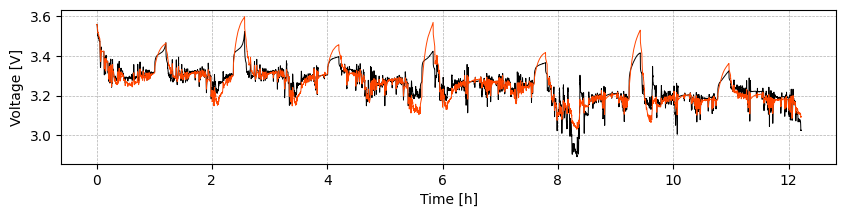

RMSE = 37.76 mV, MAE  = 24.86 mV

LPV model with n = 3


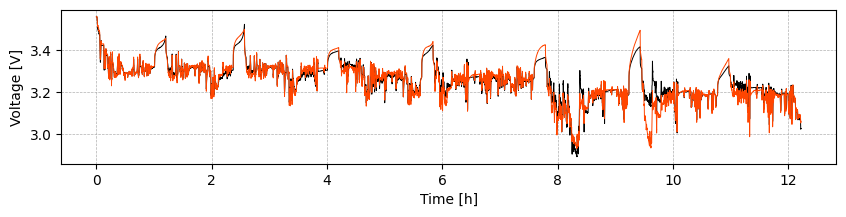

RMSE = 27.77 mV, MAE  = 15.84 mV



In [9]:
for label, model, voltage_simulated in [
    (f"LTI model with n = {model_lti.model_order}", model_lti, voltage_simulated_lti),
    (f"LPV model with n = {model_lpv.model_order}", model_lpv, voltage_simulated_lpv),
]:
    print(label)
    plot_time_vs_voltage(
        [(time_values, dataset['voltage_values']), (time_values, voltage_simulated)],
        units=('h', 'V'), colors=['k', 'orangered'], figsize=(10, 2)
    )
    rmse = root_mean_squared_error(
        voltage_simulated[:],
        dataset['voltage_values'][:]
    )
    mae = mean_absolute_error(
        voltage_simulated[:],
        dataset['voltage_values'][:]
    )
    print(f"RMSE = {rmse * 1e3:.2f} mV, "
          f"MAE  = {mae * 1e3:.2f} mV\n")

#### D. Load state-space representation

In [10]:
ss_representation_lti = StateSpace(model_lti, state_components=['s', 'overpotentials'])
ss_representation_lpv = StateSpace(model_lpv, state_components=['s', 'overpotentials'])

In [11]:
print("For LTI model")
print_statespace_equations(ss_representation_lti)
#
print("For LPV model")
print_statespace_equations(ss_representation_lpv)

For LTI model


╭───────────── State-space equations ──────────────╮
│                                                  │
│ x_{k+1} = A(p_k) · x_k + B(p_k) · u_k            │
│ V_k     = EMF(s_k, T_k) + C · x_k + D(p_k) · u_k │
│                                                  │
│ where                                            │
│                                                  │
│ x_k = [s_k, x_1,k]   (dim = 2)                   │
│ p_k = [s_k, i_k, T_k]                            │
│ u_k = i_k                                        │
│                                                  │
│          ┌               ┐                       │
│          │ 1 ¦         0 │                       │
│ A(p_k) = │ --+---------- │                       │
│          │ 0 ¦ -a_1(p_k) │                       │
│          └               ┘                       │
│                                                  │
│          ┌                              ┐        │
│          │                       Δt / ℚ │        │
│ B(p_k) = │ ---------------------------- │        │
│          │ b_1(p_k) - a_1(p_k)·b_0(p_k) │        │
│          └                              ┘        │
│                                                  │
│     ┌       ┐                                    │
│ C = │ 0 ¦ 1 │                                    │
│     └       ┘                                    │
│                                                  │
│          ┌          ┐                            │
│ D(p_k) = │ b_0(p_k) │                            │
│          └          ┘                            │
╰──────────────────────────────────────────────────╯

For LPV model


╭───────────── State-space equations ──────────────╮
│                                                  │
│ x_{k+1} = A(p_k) · x_k + B(p_k) · u_k            │
│ V_k     = EMF(s_k, T_k) + C · x_k + D(p_k) · u_k │
│                                                  │
│ where                                            │
│                                                  │
│ x_k = [s_k, x_1,k, x_2,k, x_3,k]   (dim = 4)     │
│ p_k = [s_k, i_k, T_k]                            │
│ u_k = i_k                                        │
│                                                  │
│          ┌                     ┐                 │
│          │ 1 ¦         0  0  0 │                 │
│          │ --+---------------- │                 │
│ A(p_k) = │ 0 ¦ -a_1(p_k)  1  0 │                 │
│          │ 0 ¦ -a_2(p_k)  0  1 │                 │
│          │ 0 ¦ -a_3(p_k)  0  0 │                 │
│          └                     ┘                 │
│                                                  │
│          ┌                              ┐        │
│          │                       Δt / ℚ │        │
│          │ ---------------------------- │        │
│ B(p_k) = │ b_1(p_k) - a_1(p_k)·b_0(p_k) │        │
│          │ b_2(p_k) - a_2(p_k)·b_0(p_k) │        │
│          │ b_3(p_k) - a_3(p_k)·b_0(p_k) │        │
│          └                              ┘        │
│                                                  │
│     ┌             ┐                              │
│ C = │ 0 ¦ 1  0  0 │                              │
│     └             ┘                              │
│                                                  │
│          ┌          ┐                            │
│ D(p_k) = │ b_0(p_k) │                            │
│          └          ┘                            │
╰──────────────────────────────────────────────────╯

#### E. Load EKF and run it on the dataset

In [12]:
initial_soc = 0.5
variance_eta_u = 1e-2
variance_eta_y_e = 1e-3
# Not so important parameters affecting mainly the transient behaviour.
# Nevertheless, very bad values will lead to convergence failure.
soc_error_covariance = 1
overpotential_error_covariance = 0.1

# 
start_idx = 24000
# Dataset with bad current values
dataset_for_soc_estimation = {
    'current_values': bad_current_values[start_idx:],
    'voltage_values': voltage_values[start_idx:],
    'temperature_values': temperature_values[start_idx:],
}

In [13]:
#
ekf = ExtendedKalmanFilter(statespace=ss_representation_lti,
                           variance_eta_u=variance_eta_u,
                           variance_eta_y_e=variance_eta_y_e)
# Set initial conditions
initial_state = np.array([ initial_soc, 0 ])
initial_covariance = np.diag([ soc_error_covariance, overpotential_error_covariance ])

state_estimates_lti, error_covariances = ekf.run(
    dataset=dataset_for_soc_estimation,
    initial_state=initial_state,
    initial_covariance=initial_covariance,
)
soc_estimates_lti = state_estimates_lti[:, 0]
soc_std_lti = np.sqrt(error_covariances[:, 0, 0])

EKF Progress: 100%|███████████████████████████████████████| 19978/19978 [00:03<00:00, 6505.38step/s]


In [14]:
ekf = ExtendedKalmanFilter(statespace=ss_representation_lpv,
                           variance_eta_u=variance_eta_u,
                           variance_eta_y_e=variance_eta_y_e)

# Set initial conditions
initial_state = np.array([ initial_soc ] + [0] * ss_representation_lpv.model_order)
initial_covariance = np.diag([soc_error_covariance] + [overpotential_error_covariance] * ss_representation_lpv.model_order)
#
state_estimates_lpv, error_covariances = ekf.run(
    dataset=dataset_for_soc_estimation,
    initial_state=initial_state,
    initial_covariance=initial_covariance,
)
soc_estimates_lpv = state_estimates_lpv[:, 0]
soc_std_lpv = np.sqrt(error_covariances[:, 0, 0])

EKF Progress: 100%|███████████████████████████████████████| 19978/19978 [00:12<00:00, 1661.61step/s]


In [15]:
# Coulomb counting method to calculate true SOC
soc_true = np.zeros(len(time_values))
# True initial SOC
soc_true[0] = invert_voltage_function(model_lti.emf_function, voltage_values[0])

for k in range(1, len(time_values)):
    soc_true[k] = soc_true[k - 1] + (good_current_values[k] * model_lti.sampling_period) / model_lti.battery_capacity

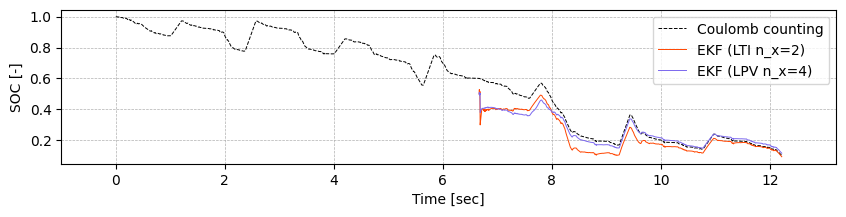

RMSE LTI: 0.0792, RMSE LPV: 0.0699


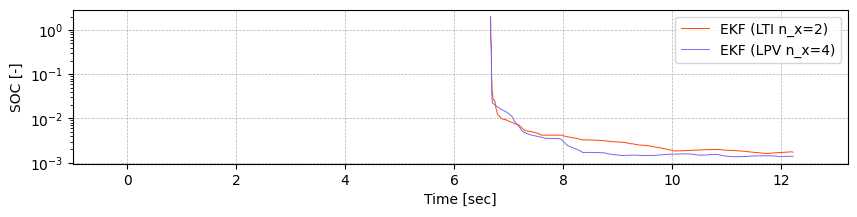

In [16]:
plot_time_vs_soc(
    [(time_values, soc_true),
     (time_values[start_idx:], soc_estimates_lti),
     (time_values[start_idx:], soc_estimates_lpv)
     ],
    colors=('k', 'orangered', 'mediumslateblue'),
    linestyles=['--'],
    legends=['Coulomb counting',
             f'EKF (LTI n_x={ss_representation_lti.state_dimension})',
             f'EKF (LPV n_x={ss_representation_lpv.state_dimension})'],
    figsize=(10, 2),
    xlims=(time_values[0] - 1, time_values[-1] + 1),
)
#
rmse_lti = root_mean_squared_error(soc_true[start_idx:], soc_estimates_lti)
rmse_lpv = root_mean_squared_error(soc_true[start_idx:], soc_estimates_lpv)
#
print(f"RMSE LTI: {rmse_lti:.4f}, RMSE LPV: {rmse_lpv:.4f}")
# 2*std_deviations
plot_time_vs_soc(
    [(time_values[start_idx:], 2*soc_std_lti),
     (time_values[start_idx:], 2*soc_std_lpv)],
    colors=('orangered', 'mediumslateblue'),
    legends=[f'EKF (LTI n_x={ss_representation_lti.state_dimension})',
             f'EKF (LPV n_x={ss_representation_lpv.state_dimension})'],
    figsize=(10, 2),
    xlims=(time_values[0] - 1, time_values[-1] + 1),
    yscale='log'
)

#### F. Conclusions

Using EKF with LPV models perform significantly better than LTI models for both NMC and LFP batteries. This reinforces the following statement, "You cannot achieve reliable state estimation without generalisable battery models", or in other words, "better models will almost always lead to better state estimates".

Under very large current sensor biases (> 1 A), SOC estimation using EKF with lower-order models (e.g. LPV or even LTI with $n=1$) is more robust, as higher-order models provide more degrees of freedom for the EKF to absorb measurement residuals into the overpotential-related states rather than correcting SOC. This robustness, however, comes at the cost of the improved nominal performance that more complex LPV models would deliver under better sensing conditions. To illustrate this behaviour, the bias may be set to 10 A (and variance_eta_u = 100) in the following. Note that this would be purely an academic investigation, as such large biases are not expected in practice.